<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Ademola_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1015]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd
import pandas

import copy
import os

In [1016]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [1017]:
try:
    from keras_visualizer import visualizer
except:
    !pip install keras-visualizer
    from keras_visualizer import visualizer

In [1018]:
import tensorflow as tf
from tensorflow.python.client import device_lib
import keras
from IPython.display import display, Image

In [1019]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
ademola_training_data = import_local_or_github('ademola_training_data', directory='../Utility')

In [1020]:
def collect_offset_rows(df, states=None, controls=None, outputs=None,
                        state_offsets=None, control_offsets=None, output_offsets=None):
    """ Takes a pandas data frame with n rows and creates an augmented data frame that collects
        rows at specified offsets for different column types (states, controls, outputs).

        Inputs
            df: pandas data frame
            states: list of column names to treat as states
            controls: list of column names to treat as controls
            outputs: list of column names to treat as outputs
            state_offsets: list of integer offsets for state columns (default: [-1])
            control_offsets: list of integer offsets for control columns (default: [-1])
            output_offsets: list of integer offsets for output columns (default: [0])

            Offset interpretation:
                - Negative values look backward (e.g., -1 is previous row, -2 is two rows back)
                - Zero includes current row
                - Positive values look forward (e.g., 1 is next row, 2 is two rows ahead)

        Outputs
            df_aug: augmented pandas data frame.
                    Columns are organized by type and offset:
                    - First all state columns (grouped by offset)
                    - Then all control columns (grouped by offset)
                    - Finally all output columns (grouped by offset)
                    New columns are named: old_name_offset_N (e.g., 'x_offset_-1', 'u_offset_0')
                    Only rows where all offsets are valid are included.
    """
    import pandas as pd
    import numpy as np
    df = df.reset_index(drop=True)

    # Set defaults
    if state_offsets is None:
        state_offsets = [-1]
    if control_offsets is None:
        control_offsets = [-1]
    if output_offsets is None:
        output_offsets = [0]

    # Collect all columns and offsets to determine valid row range
    all_columns = []
    all_offsets = []

    column_groups = []
    if states is not None and len(states) > 0:
        all_columns.extend(states)
        all_offsets.extend(state_offsets)
        column_groups.append(('states', states, state_offsets))

    if controls is not None and len(controls) > 0:
        all_columns.extend(controls)
        all_offsets.extend(control_offsets)
        column_groups.append(('controls', controls, control_offsets))

    if outputs is not None and len(outputs) > 0:
        all_columns.extend(outputs)
        all_offsets.extend(output_offsets)
        column_groups.append(('outputs', outputs, output_offsets))

    if len(all_columns) == 0:
        raise ValueError("At least one of states, controls, or outputs must be specified")

    # Determine valid row range
    min_offset = min(all_offsets)
    max_offset = max(all_offsets)

    n_row = df.shape[0]

    # Valid rows are those where all offsets point to existing rows
    start_row = max(0, -min_offset)
    end_row = min(n_row, n_row - max_offset)
    n_row_train = end_row - start_row

    if n_row_train <= 0:
        raise ValueError(f"No valid rows with given offsets. DataFrame has {n_row} rows, "
                        f"but offsets range from {min_offset} to {max_offset}")

    # Build augmented dataframe by processing each column group
    df_aug_parts = []

    for group_name, columns, offsets in column_groups:
        # For each offset in this group
        for offset in offsets:
            source_indices = np.arange(start_row, end_row) + offset

            # For each column with this offset
            for col in columns:
                data = df.loc[source_indices, col].reset_index(drop=True)
                col_name = f'{col}_offset_{offset}'
                df_aug_parts.append(pd.DataFrame({col_name: data}))

    # Combine all parts
    df_aug = pd.concat(df_aug_parts, axis=1)

    return df_aug

# Download, load, and clean data as in Lesson 11.B

In [1021]:
# Load all trajectories from the directory
directory = 'tb_trajectories'
all_fnames = [f for f in os.listdir(directory) if f.endswith('.hdf')]

traj_list = []
for fname in all_fnames:
    fpath = os.path.join(directory, fname)
    trajec = pd.read_hdf(fpath)
    traj_list.append(trajec)

print(f'Number of trajectories loaded: {len(traj_list)}')
print(f'First trajectory shape: {traj_list[0].shape}')
print(f'Columns: {list(traj_list[0].columns)}')

Number of trajectories loaded: 10
First trajectory shape: (90, 13)
Columns: ['time', 'objid', 'S', 'V', 'I', 'R', 'beta', 'sigma', 'alpha', 'kappa', 'I_absolute', 'V_absolute', 'R_absolute']


In [1022]:
def add_noise_to_trajectory_data(traj_list, noise_std):
    exclude_columns = ['time', 'objid']  # don't add noise to time or the objid!
    noise_distribution = scipy.stats.norm(0, noise_std)

    for i, trajec in enumerate(traj_list):
        for col in trajec.keys():
            if col not in exclude_columns:
                trajec[col] += noise_distribution.rvs(trajec.shape[0])
                traj_list[i] = trajec

    return traj_list

# Add small additional noise to make training more robust
noise_std = 0.0  # Set to 0 for now since measurements already have noise
traj_list = add_noise_to_trajectory_data(traj_list, noise_std)

print("Noise added to trajectories")

Noise added to trajectories


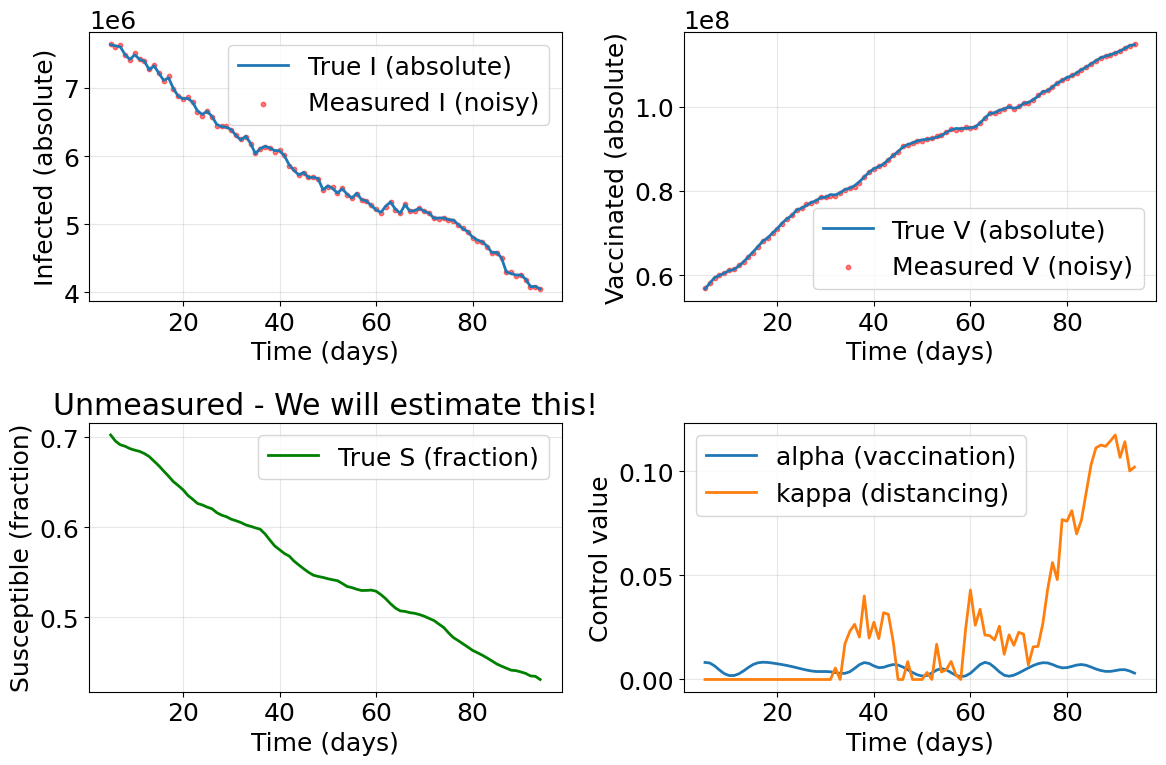

In [1023]:
# Pick a trajectory to visualize
i = 0  # Look at the first trajectory
traj = traj_list[i]

# Plot the infected population over time
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot I (infected) - true state vs noisy measurement
axes[0, 0].plot(traj.time, traj.I * 223000000, label='True I (absolute)', linewidth=2)
axes[0, 0].scatter(traj.time, traj.I_absolute, label='Measured I (noisy)', s=10, alpha=0.5, color='red')
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Infected (absolute)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot V (vaccinated) - true state vs noisy measurement
axes[0, 1].plot(traj.time, traj.V * 223000000, label='True V (absolute)', linewidth=2)
axes[0, 1].scatter(traj.time, traj.V_absolute, label='Measured V (noisy)', s=10, alpha=0.5, color='red')
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Vaccinated (absolute)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot S (susceptible) - this is what we want to ESTIMATE
axes[1, 0].plot(traj.time, traj.S, label='True S (fraction)', linewidth=2, color='green')
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Susceptible (fraction)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_title('Unmeasured - We will estimate this!')

# Plot controls
axes[1, 1].plot(traj.time, traj.alpha, label='alpha (vaccination)', linewidth=2)
axes[1, 1].plot(traj.time, traj.kappa, label='kappa (distancing)', linewidth=2)
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Control value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Define inputs and outputs for the ANN

In [1024]:
# Output: what we want to ESTIMATE (unmeasured states)
output_names = ['S', 'beta', 'sigma']

# Inputs: what we can MEASURE (noisy measurements + controls)
input_names = ['I_absolute', 'V_absolute', 'R_absolute', 'alpha', 'kappa']

# Time window: how many past time steps to use
time_window = 10  # Use past 10 days of measurements

# Construct input offsets (looking backward in time)
input_offsets = np.arange(time_window) * -1
print('Input offsets (negative = past):', input_offsets)

# We only need to estimate states at the current time
output_offsets = [0]

print(f'\nInputs: {input_names}')
print(f'Outputs: {output_names}')
print(f'Time window: {time_window} days')

Input offsets (negative = past): [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]

Inputs: ['I_absolute', 'V_absolute', 'R_absolute', 'alpha', 'kappa']
Outputs: ['S', 'beta', 'sigma']
Time window: 10 days


# Create augmented training data with time windows

In [1025]:
# Ignore the first and last few frames to prevent artifacts
trim_edges = 5

# Build augmented trajectory for each trajectory in the list
traj_augment_list = []
for traj in traj_list:
    traj_augment = collect_offset_rows(traj[trim_edges:-1*trim_edges],
                                       states=input_names,
                                       controls=None,
                                       outputs=output_names,
                                       state_offsets=input_offsets,
                                       control_offsets=None,
                                       output_offsets=output_offsets)

    traj_augment_list.append(traj_augment)

# Combine all trajectories into a single data frame
traj_augment_all = pd.concat(traj_augment_list, ignore_index=True)

print(f'Total training samples: {traj_augment_all.shape[0]}')
print(f'Total features: {traj_augment_all.shape[1]}')
print(f'\nFirst few column names:')
print(list(traj_augment_all.columns[:10]))

Total training samples: 710
Total features: 53

First few column names:
['I_absolute_offset_0', 'V_absolute_offset_0', 'R_absolute_offset_0', 'alpha_offset_0', 'kappa_offset_0', 'I_absolute_offset_-1', 'V_absolute_offset_-1', 'R_absolute_offset_-1', 'alpha_offset_-1', 'kappa_offset_-1']


#Separate inputs (X) and outputs (Y)

In [1026]:
# Calculate dimensions
n_input = len(input_names) * time_window
n_output = len(output_names)

print(f'Number of inputs: {n_input}')
print(f'Number of outputs: {n_output}')

# Input data (X): first n_input columns
X = traj_augment_all.iloc[:, 0:n_input]
print(f'\nX shape: {X.shape}')
print('X columns (first 5):', list(X.columns[:5]))

# Output data (Y): remaining columns
Y = traj_augment_all.iloc[:, n_input:]
print(f'\nY shape: {Y.shape}')
print('Y columns:', list(Y.columns))

# Show a sample
print('\n--- Sample training example ---')
print('First input row:', X.iloc[0].values[:5], '...')
print('First output row:', Y.iloc[0].values)

Number of inputs: 50
Number of outputs: 3

X shape: (710, 50)
X columns (first 5): ['I_absolute_offset_0', 'V_absolute_offset_0', 'R_absolute_offset_0', 'alpha_offset_0', 'kappa_offset_0']

Y shape: (710, 3)
Y columns: ['S_offset_0', 'beta_offset_0', 'sigma_offset_0']

--- Sample training example ---
First input row: [6.88089448e+06 7.00800984e+07 4.68873282e+06 7.89147918e-03
 0.00000000e+00] ...
First output row: [6.4629607e-01 1.0000000e-10 1.0000000e-11]


# Define the neural network architecture

In [1027]:
# Define model architecture
input_architecture = [
    {'core_input_dim': n_input},
]

core_architecture = [
    {'units': 64, 'activation': 'tanh'},
    {'units': 64, 'activation': 'tanh'},
    {'units': 32, 'activation': 'tanh'},
    {'units': n_output, 'activation': 'linear'}
]

def build_model(input_architecture, core_architecture):
    model = keras.models.Sequential()  # Sequential model (layers stacked one after another)
    n_input = input_architecture[0]['core_input_dim']

    for i, layer in enumerate(core_architecture):
        if i == 0:
            model.add(keras.layers.Dense(layer['units'],
                            input_dim=n_input,
                            activation=layer['activation']))
        else:
            model.add(keras.layers.Dense(layer['units'],
                            activation=layer['activation']))
    return model

model = build_model(input_architecture, core_architecture)

print('Neural network architecture:')
print(model.summary())


Neural network architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_93"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_372 (Dense)               │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_373 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_374 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_375 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,603 (37.51 KB)

 Trainable params: 9,603 (37.51 KB)

 Non-trainable params: 0 (0.00 B)

None


#Compile and visualize the model

Model compiled successfully!



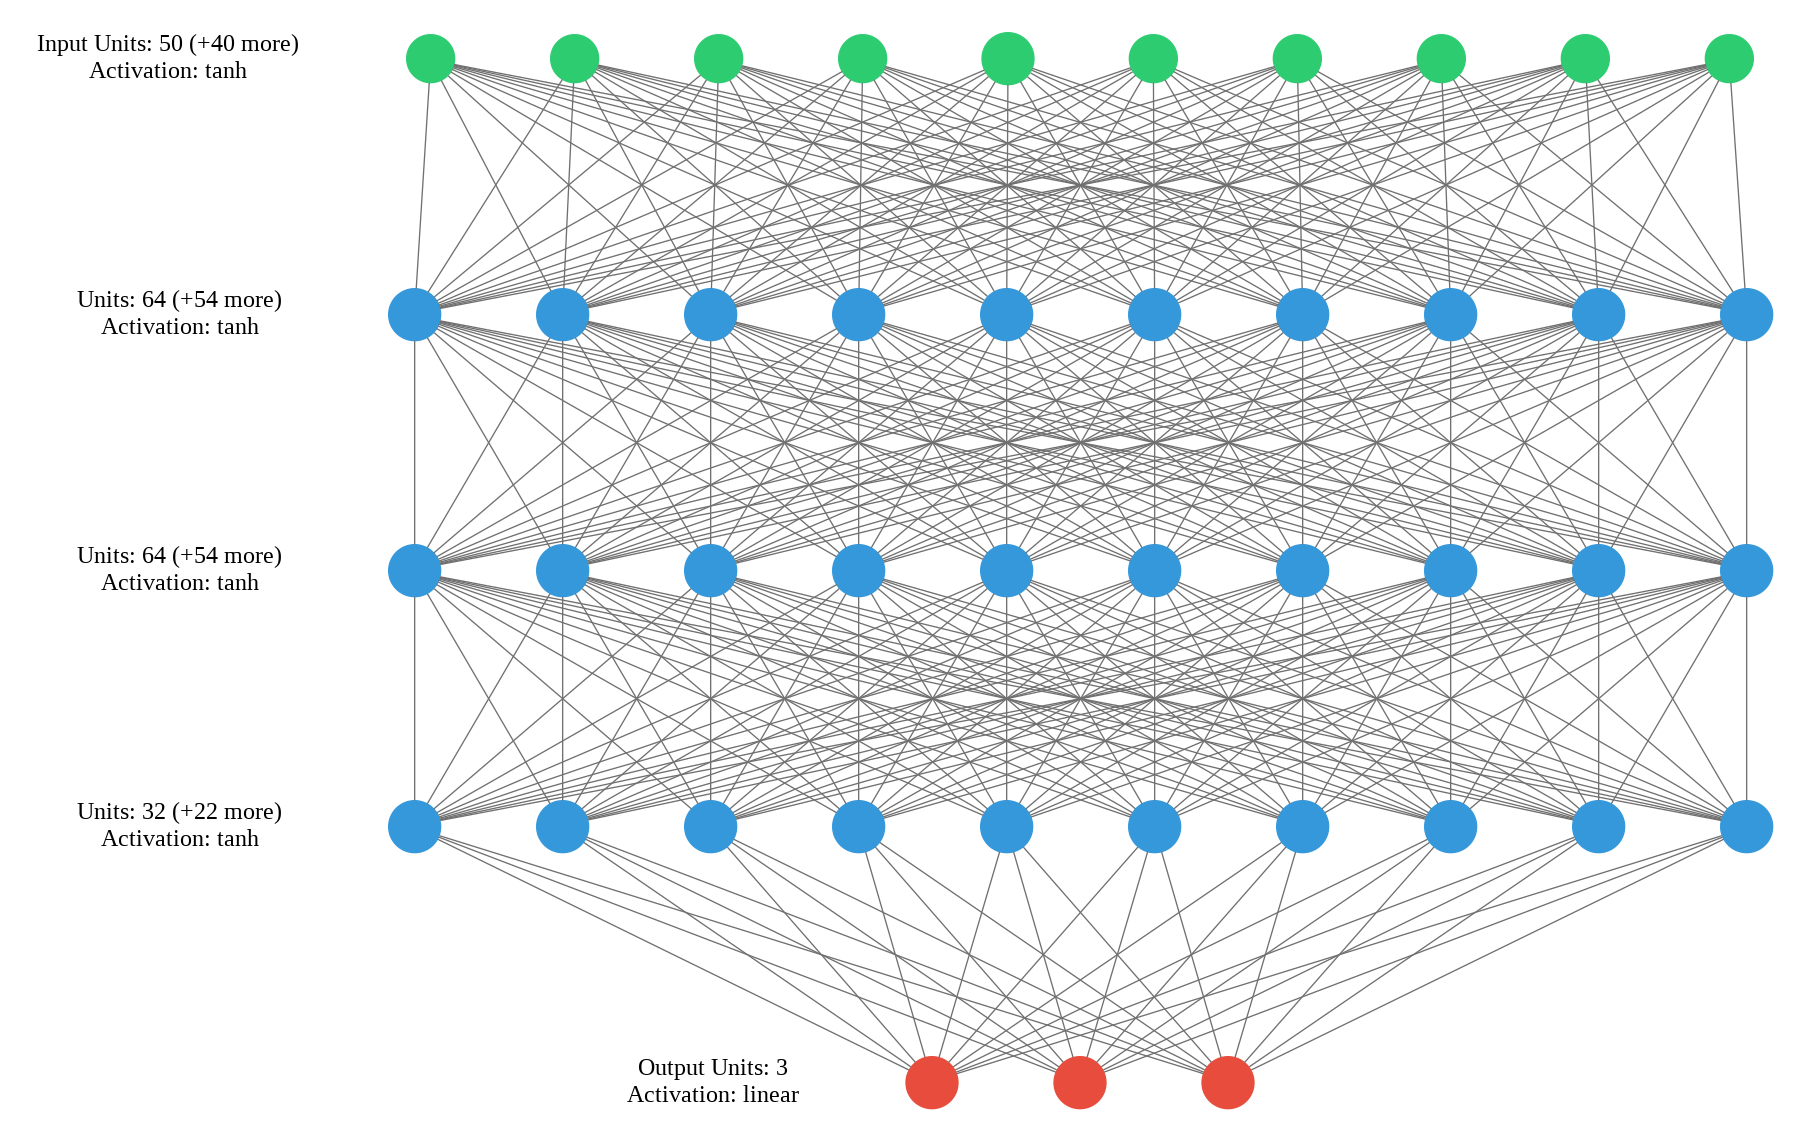

Model visualization saved as graph.png


In [1028]:
# Compile the model
model.compile(loss='mean_squared_error',  # MSE loss for regression
              optimizer='adam',  # Adam optimizer (adaptive learning rate)
              metrics=['mean_absolute_error'])  # Also track MAE

print('Model compiled successfully!\n')

# Visualize the architecture
try:
    visualizer(model, file_format='png', view=False)
    display(Image(filename='graph.png'))
    print('Model visualization saved as graph.png')
except:
    print('Could not visualize model (visualizer may not be available)')

#Training the model

In [1029]:
# Train the model
print('Starting training...\n')

model_data = model.fit(X, Y,
                       epochs=100,  # Number of times to go through entire dataset
                       batch_size=256,  # Process 256 samples at a time
                       validation_split=0.2,  # Use 20% of data for validation
                       verbose=1)  # Show progress

print('\nTraining complete!')

# Convert training history to DataFrame for easy plotting
model_history = pd.DataFrame(model_data.history)
print(f'\nFinal training loss: {model_history.loss.iloc[-1]:.6f}')
print(f'Final validation loss: {model_history.val_loss.iloc[-1]:.6f}')

Starting training...

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.5406 - mean_absolute_error: 0.6368 - val_loss: 0.1565 - val_mean_absolute_error: 0.3139
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1170 - mean_absolute_error: 0.2586 - val_loss: 0.1758 - val_mean_absolute_error: 0.3370
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0846 - mean_absolute_error: 0.2412 - val_loss: 0.1826 - val_mean_absolute_error: 0.3392
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0953 - mean_absolute_error: 0.2662 - val_loss: 0.1414 - val_mean_absolute_error: 0.3023
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0591 - mean_absolute_error: 0.2002 - val_loss: 0.1001 - val_mean_absolute_error: 0.2441
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0292 - mean_absolute_error: 0.1306 - val_loss: 0.0722 - val_mean_absolute_error: 0.2119
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0277 - mean_absolute_error: 0

# plot training history

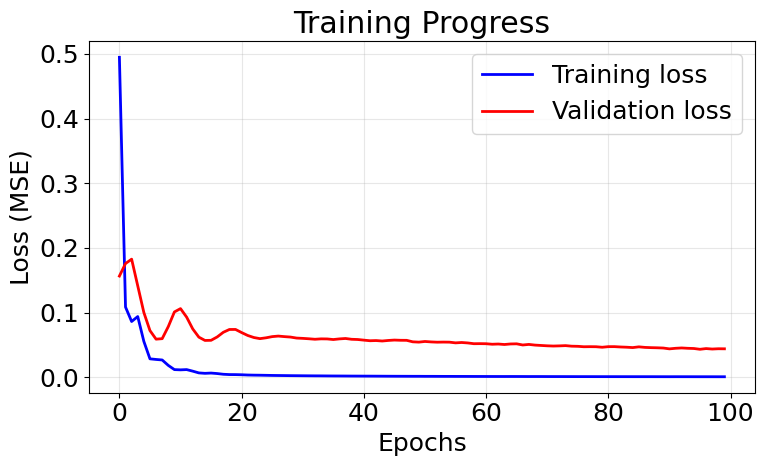

If validation loss is much higher than training loss, the model may be overfitting.
If both are decreasing, the model is learning well!


In [1030]:
# Plot training and validation loss over epochs
fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

ax.plot(model_history.loss, '-', label='Training loss', color='blue', linewidth=2)
ax.plot(model_history.val_loss, '-', label='Validation loss', color='red', linewidth=2)

ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Training Progress')

plt.tight_layout()
plt.show()

print('If validation loss is much higher than training loss, the model may be overfitting.')
print('If both are decreasing, the model is learning well!')

##  Make predictions and calculate errors

In [1031]:
# Make predictions on all training data
Y_predict = model.predict(X, batch_size=4096, verbose=0)

# Extract predictions for each output
S_predict = Y_predict[:, 0]
beta_predict = Y_predict[:, 1]
sigma_predict = Y_predict[:, 2]

# Extract true values
S_true = Y['S_offset_0'].values
beta_true = Y['beta_offset_0'].values
sigma_true = Y['sigma_offset_0'].values

# Calculate errors for S
S_error = S_predict - S_true
S_mean_error = np.mean(S_error)
S_std_error = np.std(S_error)

print('=== Susceptible (S) Estimation ===')
print(f'Mean error: {S_mean_error:.6f}')
print(f'Std error: {S_std_error:.6f}')

# Calculate errors for beta
beta_error = beta_predict - beta_true
beta_mean_error = np.mean(beta_error)
beta_std_error = np.std(beta_error)

print('\n=== Beta (transmission) Estimation ===')
print(f'Mean error: {beta_mean_error:.9f}')
print(f'Std error: {beta_std_error:.9f}')

# Calculate errors for sigma
sigma_error = sigma_predict - sigma_true
sigma_mean_error = np.mean(sigma_error)
sigma_std_error = np.std(sigma_error)

print('\n=== Sigma (transmission) Estimation ===')
print(f'Mean error: {sigma_mean_error:.9f}')
print(f'Std error: {sigma_std_error:.9f}')

=== Susceptible (S) Estimation ===
Mean error: 0.039974
Std error: 0.138418

=== Beta (transmission) Estimation ===
Mean error: 0.007098151
Std error: 0.036552559

=== Sigma (transmission) Estimation ===
Mean error: 0.026560612
Std error: 0.072192922


## Plot prediction accuracy

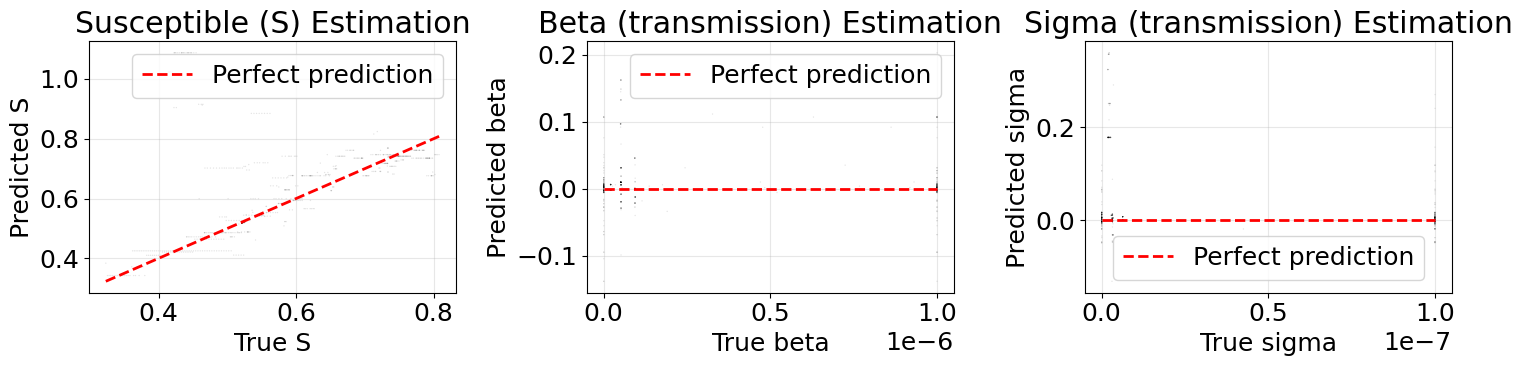

In [1032]:
# Create subplots for each output
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

# Plot S predictions vs true
axes[0].scatter(S_true, S_predict, s=1, c='black', alpha=0.1, edgecolors='none')
S_line = np.linspace(S_true.min(), S_true.max(), 100)
axes[0].plot(S_line, S_line, '--', color='red', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('True S')
axes[0].set_ylabel('Predicted S')
axes[0].set_title('Susceptible (S) Estimation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot beta predictions vs true
axes[1].scatter(beta_true, beta_predict, s=1, c='black', alpha=0.1, edgecolors='none')
beta_line = np.linspace(beta_true.min(), beta_true.max(), 100)
axes[1].plot(beta_line, beta_line, '--', color='red', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('True beta')
axes[1].set_ylabel('Predicted beta')
axes[1].set_title('Beta (transmission) Estimation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot sigma predictions vs true
axes[2].scatter(sigma_true, sigma_predict, s=1, c='black', alpha=0.1, edgecolors='none')
sigma_line = np.linspace(sigma_true.min(), sigma_true.max(), 100)
axes[2].plot(sigma_line, sigma_line, '--', color='red', linewidth=2, label='Perfect prediction')
axes[2].set_xlabel('True sigma')
axes[2].set_ylabel('Predicted sigma')
axes[2].set_title('Sigma (transmission) Estimation')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Error Histogram Distribution

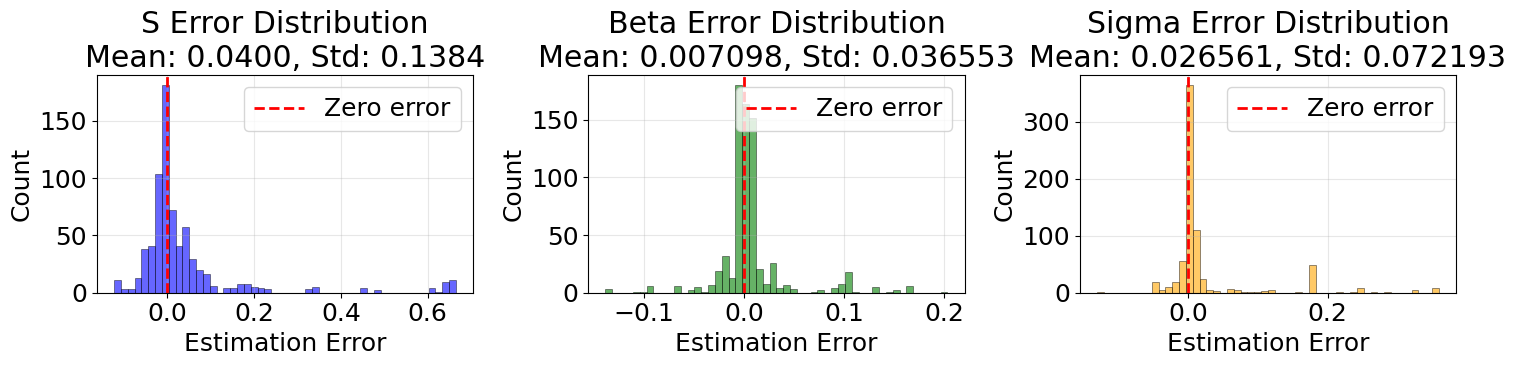

In [1033]:
# Create histogram plots for errors
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

# S error histogram
axes[0].hist(S_error, bins=50, facecolor='blue', alpha=0.6, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0].set_xlabel('Estimation Error')
axes[0].set_ylabel('Count')
axes[0].set_title(f'S Error Distribution\nMean: {S_mean_error:.4f}, Std: {S_std_error:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Beta error histogram
axes[1].hist(beta_error, bins=50, facecolor='green', alpha=0.6, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].set_xlabel('Estimation Error')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Beta Error Distribution\nMean: {beta_mean_error:.6f}, Std: {beta_std_error:.6f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sigma error histogram
axes[2].hist(sigma_error, bins=50, facecolor='orange', alpha=0.6, edgecolor='black', linewidth=0.5)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[2].set_xlabel('Estimation Error')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Sigma Error Distribution\nMean: {sigma_mean_error:.6f}, Std: {sigma_std_error:.6f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1034]:
import json

def save_model_complete(model, filepath, input_architecture, core_architecture):
    """
    Save model weights and complete configuration for easy reloading.

    Parameters:
    -----------
    model : keras.Model
        Trained model to save
    filepath : str
        Base filepath (without extension), e.g., 'my_model'
    input_architecture : dict
        Dict with 'core_input_dim'
    core_architecture : list of dict
        Core branch architecture specification
    """

    # Save weights (must end with .weights.h5)
    weights_path = f"{filepath}.weights.h5"
    model.save_weights(weights_path)
    print(f"✓ Saved weights to: {weights_path}")

    # Save complete configuration
    config = {
        'input_architecture': input_architecture,
        'core_architecture': core_architecture,
        'input_names': input_names,
        'output_names': output_names,
        'time_window': time_window
    }

    config_path = f"{filepath}_config.json"
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✓ Saved configuration to: {config_path}")

    print(f"\nModel saved successfully!")

# Save the model
save_model_complete(model, 'tb_state_estimator_ann', input_architecture, core_architecture)

# Also save as single Keras file
model_path = 'tb_state_estimator_ann.keras'
model.save(model_path)
print(f"\n✓ Also saved complete model to: {model_path}")

✓ Saved weights to: tb_state_estimator_ann.weights.h5
✓ Saved configuration to: tb_state_estimator_ann_config.json

Model saved successfully!

✓ Also saved complete model to: tb_state_estimator_ann.keras


##  Create model loading function

In [1035]:
def load_model_complete(filepath):
    """
    Load model weights and configuration.

    Parameters:
    -----------
    filepath : str
        Base filepath (without extension), same as used in save_model_complete

    Returns:
    --------
    model : keras.Model
        Loaded model ready for inference
    config : dict
        Complete configuration dictionary
    """
    import json

    # Load configuration
    config_path = f"{filepath}_config.json"
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"✓ Loaded configuration from: {config_path}")

    # Rebuild model with same architecture
    model = build_model(config['input_architecture'], config['core_architecture'])

    # Load weights
    weights_path = f"{filepath}.weights.h5"
    model.load_weights(weights_path)
    print(f"✓ Loaded weights from: {weights_path}")

    print(f"\nModel loaded successfully!")
    print(f"Input names: {config['input_names']}")
    print(f"Output names: {config['output_names']}")
    print(f"Time window: {config['time_window']}")

    return model, config

# Test loading the model
model_loaded, config_loaded = load_model_complete('tb_state_estimator_ann')

✓ Loaded configuration from: tb_state_estimator_ann_config.json
✓ Loaded weights from: tb_state_estimator_ann.weights.h5

Model loaded successfully!
Input names: ['I_absolute', 'V_absolute', 'R_absolute', 'alpha', 'kappa']
Output names: ['S', 'beta', 'sigma']
Time window: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Test the model on a new trajectory

In [1036]:
# Pick a trajectory to test (preferably one not heavily used in training)
test_traj_idx = 5  # Change this to test different trajectories
test_traj = traj_list[test_traj_idx]

print(f'Testing on trajectory {test_traj_idx}')
print(f'Trajectory length: {len(test_traj)} days')

# Create augmented data for this trajectory
test_traj_augment = collect_offset_rows(test_traj[trim_edges:-1*trim_edges],
                                        states=input_names,
                                        controls=None,
                                        outputs=output_names,
                                        state_offsets=input_offsets,
                                        control_offsets=None,
                                        output_offsets=output_offsets)

# Separate inputs and outputs
X_test = test_traj_augment.iloc[:, 0:n_input]
Y_test = test_traj_augment.iloc[:, n_input:]

# Make predictions
Y_test_predict = model_loaded.predict(X_test, verbose=0)

# Extract predictions and true values
S_test_predict = Y_test_predict[:, 0]
beta_test_predict = Y_test_predict[:, 1]
sigma_test_predict = Y_test_predict[:, 2]

S_test_true = Y_test['S_offset_0'].values
beta_test_true = Y_test['beta_offset_0'].values
sigma_test_true = Y_test['sigma_offset_0'].values

# Get corresponding time values
time_test = test_traj['time'].values[trim_edges + time_window - 1:-1*trim_edges]

print(f'\nPredictions made for {len(time_test)} time points')

Testing on trajectory 5
Trajectory length: 90 days

Predictions made for 71 time points


##Visualize predictions vs true values over time

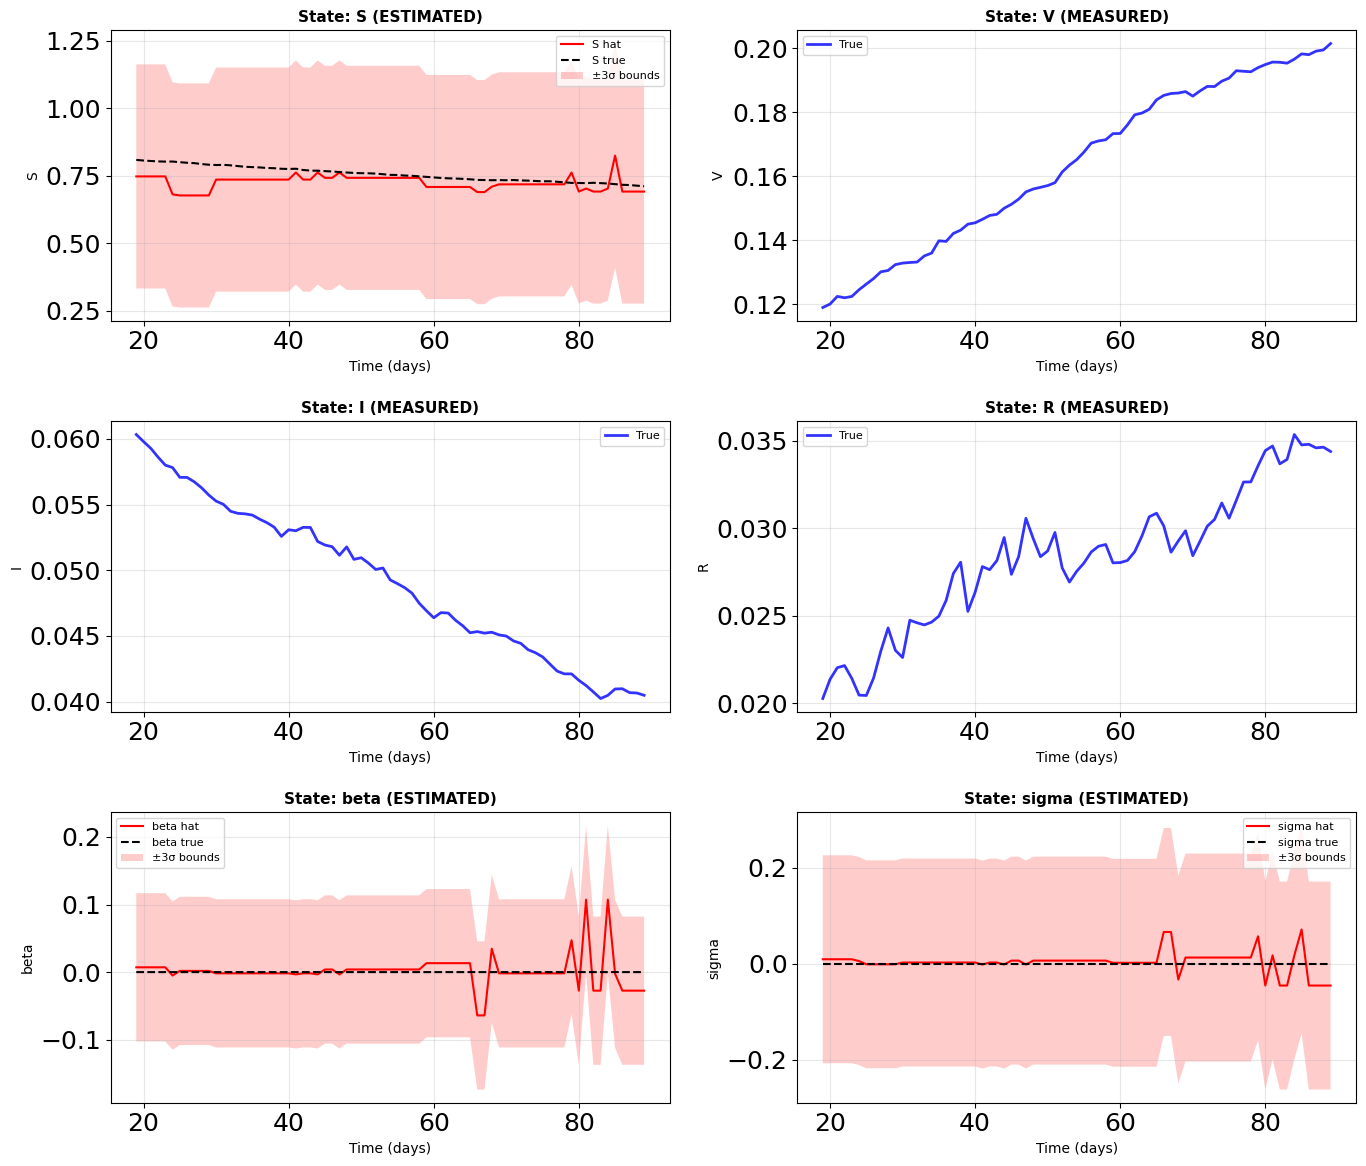


=== Summary ===
ESTIMATED states (from ANN): S, beta, sigma
MEASURED states (from sensors): V, I, R

Uncertainty (±3σ):
  S: ±0.415255
  beta: ±0.109657676
  sigma: ±0.216578766


In [1037]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate uncertainty bounds from training errors
# Use the standard deviation of errors as our uncertainty estimate
S_uncertainty = S_std_error
beta_uncertainty = beta_std_error
sigma_uncertainty = sigma_std_error

# Get all state names
state_names = ['S', 'V', 'I', 'R', 'beta', 'sigma']
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Get true values from the test trajectory (trim to match predictions)
S_true_full = test_traj['S'].values[trim_edges + time_window - 1:-1*trim_edges]
V_true_full = test_traj['V'].values[trim_edges + time_window - 1:-1*trim_edges]
I_true_full = test_traj['I'].values[trim_edges + time_window - 1:-1*trim_edges]
R_true_full = test_traj['R'].values[trim_edges + time_window - 1:-1*trim_edges]
beta_true_full = test_traj['beta'].values[trim_edges + time_window - 1:-1*trim_edges]
sigma_true_full = test_traj['sigma'].values[trim_edges + time_window - 1:-1*trim_edges]

all_true = [S_true_full, V_true_full, I_true_full, R_true_full, beta_true_full, sigma_true_full]
all_predict = [S_test_predict, None, None, None, beta_test_predict, sigma_test_predict]
all_uncertainty = [S_uncertainty, None, None, None, beta_uncertainty, sigma_uncertainty]

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    true_vals = all_true[i]
    pred_vals = all_predict[i]
    uncertainty = all_uncertainty[i]

    if pred_vals is not None:
        # Unmeasured states - show true and predicted
        plot_tme(time_test, true_vals, None, pred_vals,
                label_var=state, ax=ax)

        # Add 3-sigma uncertainty bounds
        plus_3sigma = pred_vals + 3 * uncertainty
        minus_3sigma = pred_vals - 3 * uncertainty
        ax.fill_between(time_test, plus_3sigma, minus_3sigma,
                        facecolor='red', edgecolor='none', alpha=0.2,
                        label='±3σ bounds')

        ax.set_title(f'State: {state} (ESTIMATED)', fontsize=11, fontweight='bold')
    else:
        # Measured states - only show true
        ax.plot(time_test, true_vals, 'b-', linewidth=2, label='True', alpha=0.8)
        ax.set_title(f'State: {state} (MEASURED)', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print summary
print('\n=== Summary ===')
print('ESTIMATED states (from ANN): S, beta, sigma')
print('MEASURED states (from sensors): V, I, R')
print(f'\nUncertainty (±3σ):')
print(f'  S: ±{3*S_uncertainty:.6f}')
print(f'  beta: ±{3*beta_uncertainty:.9f}')
print(f'  sigma: ±{3*sigma_uncertainty:.9f}')

#Predictions